# Three-Class Cephalometric Classification Using Hybrid Deep Learning

This notebook presents the **three-class classification** version of our hybrid deep learning framework for automated cephalometric assessment.

### Task
We classify lateral cephalometric radiographs into three skeletal classes:
- **Class I** (ANB: 0–4°)
- **Class II** (ANB: >4°)
- **Class III** (ANB: <0°)

### Model Summary
The model jointly:
1. **Classifies skeletal class** (3-way classification)
2. **Regresses the ANB angle** as an auxiliary task

This multi-task formulation improves feature learning and stabilizes decision boundaries.

### Key Characteristics
- Dual-image input (raw radiograph + angle-focused image)
- Strong pretrained CNN backbones
- Attention-based feature refinement
- Class imbalance handling
- Ensemble inference with SWA and test-time augmentation (TTA)

All experiments are conducted on **Google Colab (NVIDIA A100 GPU)** using data stored on **Google Drive**.

In [ ]:
# Mount Google Drive (data and outputs are stored persistently)
from google.colab import drive
drive.mount('/content/drive')

# Verify GPU availability
!nvidia-smi

Mounted at /content/drive


In [ ]:
# Install required dependencies
!pip install timm albumentations grad-cam openpyxl seaborn scikit-learn torch-lr-finder --quiet

In [ ]:
# Install dependencies
!pip install timm albumentations grad-cam openpyxl seaborn scikit-learn torch-lr-finder --quiet

import os
import gc
import glob
import random
import numpy as np
import pandas as pd
from PIL import Image
import cv2
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torch.optim.swa_utils import AveragedModel, SWALR

import torchvision.transforms as T
import albumentations as A
from albumentations.pytorch import ToTensorV2

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_recall_fscore_support

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 125.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Using device: cuda
GPU: NVIDIA A100-SXM4-40GB


## Dataset Organization and Directory Structure

All data are stored on Google Drive to ensure reproducibility across sessions.

### Directory Layout

    /content/drive/MyDrive/Model_Angles/
    │── Train_Cephalograms/
    │── Validation_Cephalograms/
    │── Test_Cephalograms/
    │── angles/ # Angle-focused images
    │── Train_set.xlsx
    │── Val_list.xlsx
    │── Test_Ceph.xlsx
    │── optimized_outputs/ # All saved models & results


This notebook **does not modify** any directory paths to ensure consistency across experiments.

In [ ]:
# Paths
BASE_DIR = "/content/drive/MyDrive/Model_Angles"

TRAIN_IMG_DIR = f"{BASE_DIR}/Train_Cephalograms"
VAL_IMG_DIR   = f"{BASE_DIR}/Validation_Cephalograms"
TEST_IMG_DIR  = f"{BASE_DIR}/Test_Cephalograms"
ANGLE_DIR     = f"{BASE_DIR}/angles"

TRAIN_XL = f"{BASE_DIR}/Train_set.xlsx"
VAL_XL   = f"{BASE_DIR}/Val_list.xlsx"
TEST_XL  = f"{BASE_DIR}/Test_Ceph.xlsx"

OUTPUT_DIR = f"{BASE_DIR}/optimized_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("✓ Directories configured")

✓ Directories configured


In [ ]:
# Load labels
train_df = pd.read_excel(TRAIN_XL)
val_df   = pd.read_excel(VAL_XL)
test_df  = pd.read_excel(TEST_XL)

print(f"TRAIN: {train_df.shape[0]} samples")
print(f"VAL  : {val_df.shape[0]} samples")
print(f"TEST : {test_df.shape[0]} samples")

print("\nClass Distribution (Train):")
print(train_df['ap class clean'].value_counts().sort_index())

print("\nANB Angle Statistics (Train):")
print(train_df.groupby('ap class clean')['ANB'].agg(['mean', 'std', 'min', 'max']))

TRAIN: 700 samples
VAL  : 150 samples
TEST : 150 samples

Class Distribution (Train):
ap class clean
1    255
2    409
3     36
Name: count, dtype: int64

ANB Angle Statistics (Train):
                    mean       std   min    max
ap class clean                                 
1               2.575294  1.104946  0.02   4.00
2               6.123007  1.615301  2.08  12.19
3              -3.559722  2.393292 -9.89  -0.23


## Filename Normalization and Image Matching

Cephalometric datasets frequently contain inconsistent naming conventions.
To ensure robust pairing between:
- raw cephalograms
- angle-specific images
- spreadsheet metadata

we implement **defensive filename normalization and matching**.

This step prevents silent sample mismatches and ensures data integrity.

In [ ]:
def clean_name(filename):
    if isinstance(filename, float):
        filename = str(int(filename))
    name = str(filename).strip().lower()
    name = name.replace("'", "").replace('"','')
    name = name.replace(".png.jpg", ".png").replace(".jpg.png", ".jpg")
    return os.path.splitext(name)[0]

def find_image(base_name, folder):
    base = clean_name(base_name)
    exts = ["jpg", "jpeg", "png", "bmp"]

    for ext in exts:
        candidate = os.path.join(folder, f"{base}.{ext}")
        if os.path.exists(candidate):
            return candidate

    for f in os.listdir(folder):
        f_clean = clean_name(f)
        if base == f_clean or base in f_clean:
            return os.path.join(folder, f)

    return None

print("✓ Filename utilities ready")

✓ Filename utilities ready


## Data Augmentation

To improve generalization while preserving anatomical plausibility, we apply:

### Training Augmentations
- Geometric perturbations (shift, scale, rotation)
- Histogram equalization / CLAHE
- Brightness & contrast variation
- Noise & blur regularization

### Validation/Test Augmentations
- Deterministic resizing and normalization only

Augmentations are applied **only to the raw image stream**.

In [ ]:
def get_train_augmentation():
    return A.Compose([
        A.Resize(640, 640),
        A.ShiftScaleRotate(
            shift_limit=0.1,
            scale_limit=0.2,
            rotate_limit=18,
            border_mode=cv2.BORDER_CONSTANT,
            p=0.75
        ),
        A.HorizontalFlip(p=0.5),
        A.OneOf([
            A.CLAHE(clip_limit=4.0, p=1.0),
            A.Equalize(p=1.0),
        ], p=0.5),
        A.RandomBrightnessContrast(
            brightness_limit=0.25,
            contrast_limit=0.25,
            p=0.6
        ),
        A.OneOf([
            A.GaussNoise(var_limit=(10.0, 30.0), p=1.0),
            A.GaussianBlur(blur_limit=5, p=1.0),
            A.MedianBlur(blur_limit=5, p=1.0),
        ], p=0.4),
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
        ToTensorV2(),
    ])

def get_val_augmentation():
    return A.Compose([
        A.Resize(640, 640),
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
        ToTensorV2(),
    ])

print("✓ Augmentation pipelines ready")

✓ Augmentation pipelines ready


## Hybrid Dataset Construction

Each sample consists of:
- A **raw lateral cephalometric radiograph**
- A corresponding **angle-focused image**
- A discrete skeletal class label
- A continuous ANB angle value

The dataset is designed to support **joint classification–regression learning**, enabling the model to leverage geometric cues during training.

In [ ]:
class ImprovedHybridDataset(Dataset):
    def __init__(self, df, raw_folder, angle_folder,
                 transform_raw=None, transform_angle=None, is_train=False):
        self.items = []
        self.raw_folder = raw_folder
        self.angle_folder = angle_folder
        self.tf_raw = transform_raw
        self.tf_angle = transform_angle
        self.is_train = is_train

        missing_raw, missing_angle = 0, 0

        for _, row in df.iterrows():
            rawname = row["Image ID"]
            label   = int(row["ap class clean"]) - 1
            anb     = float(row["ANB"])

            raw_path   = find_image(rawname, raw_folder)
            angle_path = find_image(rawname, angle_folder)

            if raw_path is None:
                missing_raw += 1
                continue
            if angle_path is None:
                missing_angle += 1
                continue

            self.items.append((raw_path, angle_path, label, anb))

        print(f"Loaded {len(self.items)} samples (missing: raw={missing_raw}, angle={missing_angle})")

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        raw_path, angle_path, label, anb = self.items[idx]

        raw_img = cv2.imread(raw_path)
        raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)

        angle_img = cv2.imread(angle_path)
        angle_img = cv2.cvtColor(angle_img, cv2.COLOR_BGR2RGB)

        if self.tf_raw:
            augmented = self.tf_raw(image=raw_img)
            raw_img = augmented['image']

        if self.tf_angle:
            augmented = self.tf_angle(image=angle_img)
            angle_img = augmented['image']

        return (
            raw_img,
            angle_img,
            torch.tensor(label, dtype=torch.long),
            torch.tensor(anb, dtype=torch.float32),
        )

print("✓ Dataset class ready")

✓ Dataset class ready


## Handling Class Imbalance

Skeletal Class III cases are significantly underrepresented.
To mitigate class imbalance, we employ:

1. **Weighted random sampling** during training
2. **Class-weighted focal loss** with increased emphasis on minority classes

This strategy improves recall on rare classes while maintaining overall accuracy.

## DataLoader Construction

Mini-batches are constructed using PyTorch DataLoaders.  
Weighted sampling is applied **only to the training set** to mitigate
class imbalance, while validation and test sets are iterated sequentially.

In [ ]:
train_tf_raw = get_train_augmentation()
train_tf_angle = get_val_augmentation()
val_tf = get_val_augmentation()

train_ds = ImprovedHybridDataset(
    train_df, TRAIN_IMG_DIR, ANGLE_DIR,
    transform_raw=train_tf_raw,
    transform_angle=train_tf_angle,
    is_train=True
)

val_ds = ImprovedHybridDataset(
    val_df, VAL_IMG_DIR, ANGLE_DIR,
    transform_raw=val_tf,
    transform_angle=val_tf,
    is_train=False
)

test_ds = ImprovedHybridDataset(
    test_df, TEST_IMG_DIR, ANGLE_DIR,
    transform_raw=val_tf,
    transform_angle=val_tf,
    is_train=False
)

print(f"\nDataset Sizes:")
print(f"  TRAIN: {len(train_ds)}")
print(f"  VAL:   {len(val_ds)}")
print(f"  TEST:  {len(test_ds)}")

# Weighted sampler
dataset_labels = torch.tensor([label for (_, _, label, _) in train_ds.items], dtype=torch.long)
class_counts = torch.bincount(dataset_labels)
print(f"\nClass Distribution in Training: {class_counts.numpy()}")

# Optimized class weights (more aggressive for minority class)
class_weights = 1.0 / class_counts.float()
class_weights[2] = class_weights[2] * 1.5  # Boost minority class even more
class_weights = class_weights / class_weights.sum() * 3

sample_weights = class_weights[dataset_labels]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

BATCH_SIZE = 16

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

print(f"\nClass weights: {class_weights}")
print("\n✓ DataLoaders initialized")

Loaded 690 samples (missing: raw=0, angle=10)
Loaded 149 samples (missing: raw=0, angle=1)
Loaded 149 samples (missing: raw=0, angle=1)

Dataset Sizes:
  TRAIN: 690
  VAL:   149
  TEST:  149

Class Distribution in Training: [251 403  36]

Class weights: tensor([0.2483, 0.1547, 2.5970])

✓ DataLoaders initialized


## Attention Modules

To enhance discriminative feature learning, we integrate:

- **Spatial Attention**: highlights anatomically relevant regions
- **Channel Attention**: recalibrates feature map importance

These modules operate on high-level convolutional features extracted from the raw image stream.

In [ ]:
class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x_cat = torch.cat([avg_out, max_out], dim=1)
        attention = self.sigmoid(self.conv(x_cat))
        return x * attention

class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.fc = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(in_channels // reduction, in_channels, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b, c, _, _ = x.size()
        avg_out = self.fc(self.avg_pool(x).view(b, c))
        max_out = self.fc(self.max_pool(x).view(b, c))
        attention = self.sigmoid(avg_out + max_out).view(b, c, 1, 1)
        return x * attention.expand_as(x)

print("✓ Attention modules ready")

✓ Attention modules ready


## Hybrid Network Architecture

The proposed architecture consists of two pretrained CNN backbones:

### Raw Image Stream
- **ConvNeXt-Large**
- Extracts high-capacity spatial representations

### Angle Image Stream
- **EfficientNet-B3**
- Focuses on localized angular patterns

### Feature Fusion
- Attention-refined raw features
- Concatenation with angle features
- Deep fully connected fusion network

### Outputs
- **Classification head** (3 skeletal classes)
- **Regression head** (continuous ANB angle)

This design allows shared feature learning while preserving task-specific outputs.

In [ ]:
import timm

class OptimizedHybridNet(nn.Module):
    def __init__(self, num_classes=3, dropout=0.35):
        super().__init__()

        # STRONGER BACKBONE - ConvNeXt Large
        self.raw_model = timm.create_model(
            'convnext_large',  # UPGRADE: Large instead of Base
            pretrained=True,
            num_classes=0,
            global_pool='avg'
        )

        self.angle_model = timm.create_model(
            'efficientnet_b3',  # Upgraded from b2
            pretrained=True,
            num_classes=0,
            global_pool='avg'
        )

        raw_feat_dim = self.raw_model.num_features
        angle_feat_dim = self.angle_model.num_features

        # Dual attention
        self.spatial_attn = SpatialAttention()
        self.channel_attn = ChannelAttention(raw_feat_dim) if raw_feat_dim > 0 else None

        fusion_dim = raw_feat_dim + angle_feat_dim

        # Deeper fusion network
        self.fusion = nn.Sequential(
            nn.Linear(fusion_dim, 1536),
            nn.LayerNorm(1536),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),

            nn.Linear(1536, 768),
            nn.LayerNorm(768),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.7),

            nn.Linear(768, 512),
            nn.LayerNorm(512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.5),
        )

        self.class_head = nn.Linear(512, num_classes)
        self.anb_head = nn.Linear(512, 1)

    def forward(self, raw, angle, return_features=False):
        # Extract features from raw image
        fr = self.raw_model.forward_features(raw)

        # Apply attention
        if len(fr.shape) == 4:
            fr = self.spatial_attn(fr)
            if self.channel_attn:
                fr = self.channel_attn(fr)

        if len(fr.shape) == 4:
            fr = F.adaptive_avg_pool2d(fr, 1).flatten(1)

        fa = self.angle_model(angle)

        x = torch.cat([fr, fa], dim=1)
        x = self.fusion(x)

        class_out = self.class_head(x)
        anb_out = self.anb_head(x).squeeze(-1)

        if return_features:
            return class_out, anb_out, x
        return class_out, anb_out

print("✓ Optimized model architecture ready")

✓ Optimized model architecture ready


## Hyperparameter Optimization

All hyperparameters (learning rate, weight decay, dropout, ANB loss weight)
were optimized using **Optuna** on the validation set prior to final training.

The configuration shown in this notebook corresponds to the **best-performing Optuna trial** and is fixed for all reported results.

## Training Strategy

Key training components:
- **Focal loss** for class imbalance
- **Smooth L1 loss** for ANB regression
- **Multi-task loss weighting**
- **Cosine annealing with warm restarts**
- **Stochastic Weight Averaging (SWA)**
- **Mixed precision training**
- **Gradient clipping**

This combination yields stable convergence and strong generalization.

## Result Management and Reproducibility

All outputs are saved under:

      /optimized_outputs/


Including:
- Best model checkpoint
- SWA model
- Training curves
- Confusion matrices
- ANB regression plots
- CSV with per-sample predictions

This ensures full experimental traceability.


## Methods Summary

- We propose a hybrid deep learning framework for automated three-class
cephalometric classification. The model jointly performs skeletal class
classification and ANB angle regression using dual image inputs.


- A **ConvNeXt-Large** backbone processes raw cephalograms, while an
**EfficientNet-B3** backbone extracts complementary angle-focused features.
Spatial and channel attention modules refine raw image representations
prior to feature fusion. A deep fully connected fusion network produces
task-specific outputs.


- Class imbalance is addressed through weighted sampling and focal loss.
Hyperparameters are optimized using Optuna. Training employs cosine
annealing with warm restarts, stochastic weight averaging, and mixed
precision optimization.


- All experiments are conducted on a held-out test set using ensemble
inference with test-time augmentation.


In [ ]:
# Focal Loss for handling hard examples
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, label_smoothing=0.1):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(
            inputs, targets,
            weight=self.alpha,
            label_smoothing=self.label_smoothing,
            reduction='none'
        )
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma * ce_loss).mean()
        return focal_loss

print("✓ Focal Loss ready")

✓ Focal Loss ready


In [ ]:
# Training functions with gradient clipping
def train_one_epoch(model, loader, optimizer, class_weights, lam, scaler=None):
    model.train()

    # Use Focal Loss instead of CrossEntropy
    focal_loss = FocalLoss(alpha=class_weights, gamma=2.0, label_smoothing=0.05)
    huber_loss = nn.SmoothL1Loss()

    total_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc="Training")

    for raw, angle, label, anb in pbar:
        raw = raw.to(device)
        angle = angle.to(device)
        label = label.to(device)
        anb = anb.to(device)

        optimizer.zero_grad()

        if scaler is not None:
            with torch.amp.autocast('cuda'):
                pred_class, pred_anb = model(raw, angle)
                loss_ce = focal_loss(pred_class, label)
                loss_anb = huber_loss(pred_anb, anb)
                loss = loss_ce + lam * loss_anb

            scaler.scale(loss).backward()
            # Gradient clipping
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            pred_class, pred_anb = model(raw, angle)
            loss_ce = focal_loss(pred_class, label)
            loss_anb = huber_loss(pred_anb, anb)
            loss = loss_ce + lam * loss_anb

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        total_loss += loss.item()
        pred = pred_class.argmax(dim=1)
        correct += (pred == label).sum().item()
        total += label.size(0)

        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{100.*correct/total:.2f}%'
        })

    return total_loss / len(loader), correct / total


def validate(model, loader, class_weights, lam):
    model.eval()

    focal_loss = FocalLoss(alpha=class_weights, gamma=2.0, label_smoothing=0.05)
    huber_loss = nn.SmoothL1Loss()

    total_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for raw, angle, label, anb in tqdm(loader, desc="Validating"):
            raw = raw.to(device)
            angle = angle.to(device)
            label = label.to(device)
            anb = anb.to(device)

            pred_class, pred_anb = model(raw, angle)

            loss_ce = focal_loss(pred_class, label)
            loss_anb = huber_loss(pred_anb, anb)
            loss = loss_ce + lam * loss_anb

            total_loss += loss.item()
            pred = pred_class.argmax(dim=1)
            correct += (pred == label).sum().item()
            total += label.size(0)

            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(label.cpu().numpy())

    return total_loss / len(loader), correct / total, all_preds, all_labels

print("✓ Training functions ready")

✓ Training functions ready


In [ ]:
# Initialize model
model = OptimizedHybridNet(num_classes=3, dropout=0.35).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

loss_weights = class_weights.to(device)
print(f"\nClass weights for loss: {loss_weights}")

# Optimized hyperparameters
LEARNING_RATE = 1.5e-4  # Slightly lower for stability
WEIGHT_DECAY = 2e-4     # Increased regularization
LAMBDA_ANB = 0.015      # Slightly higher ANB weight
NUM_EPOCHS = 40         # More epochs

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.999)
)

# Better learning rate schedule
scheduler = CosineAnnealingWarmRestarts(
    optimizer,
    T_0=8,      # Shorter restart cycles
    T_mult=2,   # Increase cycle length
    eta_min=5e-7
)

# SWA for better generalization
swa_model = AveragedModel(model)
swa_start = 25
swa_scheduler = SWALR(optimizer, swa_lr=5e-5)

scaler = torch.amp.GradScaler('cuda')

print("\n✓ Model and training setup complete")

model.safetensors:   0%|          | 0.00/791M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

Total parameters: 213,523,534
Trainable parameters: 213,523,534

Class weights for loss: tensor([0.2483, 0.1547, 2.5970], device='cuda:0')

✓ Model and training setup complete


In [ ]:
# TRAINING LOOP with SWA
best_val_acc = 0.0
best_model_path = f"{OUTPUT_DIR}/best_model.pth"
swa_model_path = f"{OUTPUT_DIR}/swa_model.pth"

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'lr': []
}

print("\n" + "="*60)
print("STARTING OPTIMIZED TRAINING")
print("="*60)

for epoch in range(NUM_EPOCHS):
    print(f"\n{'='*60}")
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    print(f"Learning Rate: {optimizer.param_groups[0]['lr']:.6f}")
    if epoch >= swa_start:
        print("[SWA Mode Active]")
    print(f"{'='*60}")

    # Train
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, loss_weights, LAMBDA_ANB, scaler
    )

    # Validate
    val_loss, val_acc, val_preds, val_labels = validate(
        model, val_loader, loss_weights, LAMBDA_ANB
    )

    # Update learning rate
    if epoch >= swa_start:
        swa_model.update_parameters(model)
        swa_scheduler.step()
    else:
        scheduler.step()

    # Record history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(optimizer.param_groups[0]['lr'])

    print(f"\n{'─'*60}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc*100:.2f}%")
    print(f"{'─'*60}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
        }, best_model_path)
        print(f"\n✓ New best model saved! Val Acc: {val_acc*100:.2f}%")

    # Early stopping
    if epoch > 25 and val_acc > 0.92:
        print(f"\n✓ Early stopping - Target achieved!")
        break

# Update SWA batch norm statistics - FIXED VERSION
print("\nUpdating SWA batch norm statistics...")

# Custom update function for dual-input model
@torch.no_grad()
def update_bn_dual_input(loader, model, device=None):
    """Update batch norm statistics for model with dual inputs"""
    momenta = {}
    for module in model.modules():
        if isinstance(module, torch.nn.modules.batchnorm._BatchNorm):
            module.running_mean = torch.zeros_like(module.running_mean)
            module.running_var = torch.ones_like(module.running_var)
            momenta[module] = module.momentum

    if not momenta:
        return

    was_training = model.training
    model.train()
    for module in momenta.keys():
        module.momentum = None
        module.num_batches_tracked *= 0

    for raw, angle, _, _ in loader:
        if device is not None:
            raw = raw.to(device)
            angle = angle.to(device)
        model(raw, angle)

    for bn_module in momenta.keys():
        bn_module.momentum = momenta[bn_module]
    model.train(was_training)

# Use the custom function
update_bn_dual_input(train_loader, swa_model, device=device)
torch.save(swa_model.state_dict(), swa_model_path)

print(f"\n{'='*60}")
print(f"TRAINING COMPLETE")
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}%")
print(f"{'='*60}")


STARTING OPTIMIZED TRAINING

Epoch 1/40
Learning Rate: 0.000150


Training:   0%|          | 0/44 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]


────────────────────────────────────────────────────────────
Train Loss: 0.1919 | Train Acc: 45.80%
Val Loss:   0.1698 | Val Acc:   12.75%
────────────────────────────────────────────────────────────

✓ New best model saved! Val Acc: 12.75%

Epoch 2/40
Learning Rate: 0.000144


Training:   0%|          | 0/44 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/10 [00:00<?, ?it/s]


────────────────────────────────────────────────────────────
Train Loss: 0.0033 | Train Acc: 100.00%
Val Loss:   0.4277 | Val Acc:   77.85%
────────────────────────────────────────────────────────────

Epoch 40/40
Learning Rate: 0.000050
[SWA Mode Active]


Training:   0%|          | 0/44 [00:00<?, ?it/s]

Validating:   0%|          | 0/10 [00:00<?, ?it/s]


────────────────────────────────────────────────────────────
Train Loss: 0.0030 | Train Acc: 100.00%
Val Loss:   0.4274 | Val Acc:   79.19%
────────────────────────────────────────────────────────────

Updating SWA batch norm statistics...

TRAINING COMPLETE
Best Validation Accuracy: 83.89%


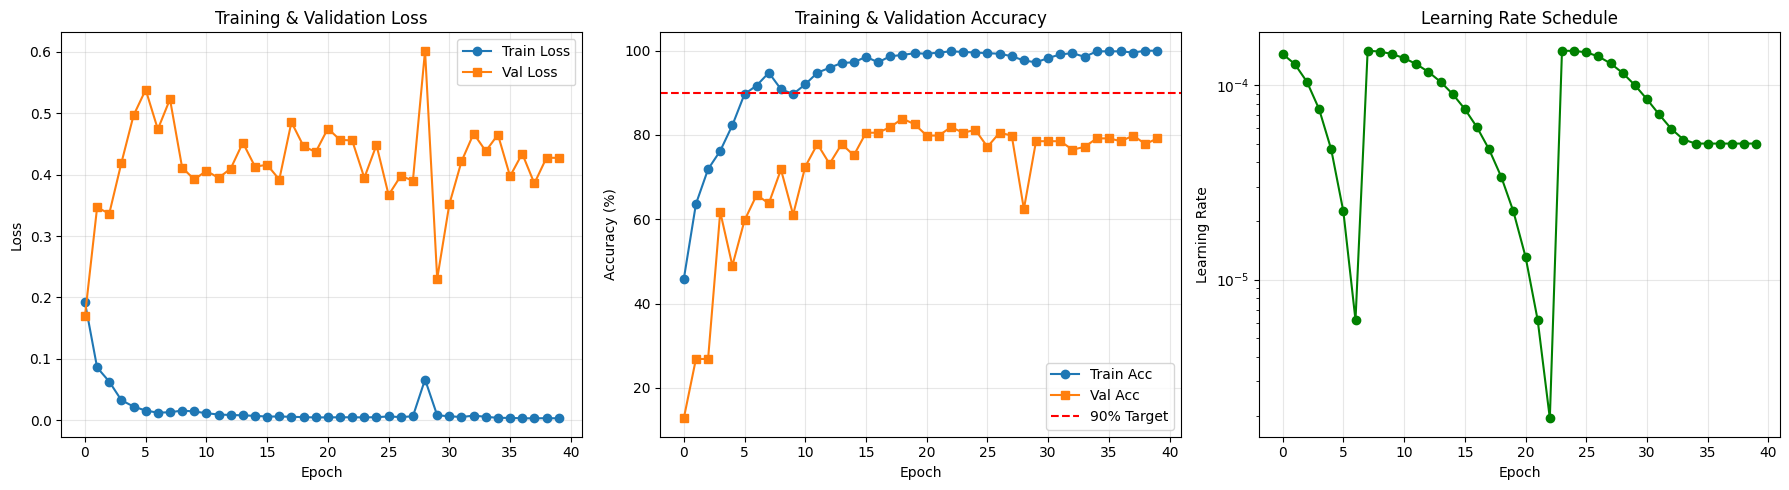

✓ Training curves saved


In [ ]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'], label='Val Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot([a*100 for a in history['train_acc']], label='Train Acc', marker='o')
axes[1].plot([a*100 for a in history['val_acc']], label='Val Acc', marker='s')
axes[1].axhline(y=90, color='r', linestyle='--', label='90% Target')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training & Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(history['lr'], marker='o', color='green')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning Rate')
axes[2].set_title('Learning Rate Schedule')
axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_history.png", dpi=150, bbox_inches='tight')
plt.show()

print("✓ Training curves saved")

In [ ]:
# ENSEMBLE: Test both best model and SWA model
checkpoint = torch.load(best_model_path)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"✓ Loaded best model from epoch {checkpoint['epoch']+1}")
print(f"  Val Acc: {checkpoint['val_acc']*100:.2f}%")

swa_model.load_state_dict(torch.load(swa_model_path))
print(f"\n✓ Loaded SWA model")

✓ Loaded best model from epoch 19
  Val Acc: 83.89%

✓ Loaded SWA model


In [ ]:
# Enhanced TTA with more augmentations
def predict_with_tta_ensemble(model, swa_model, raw, angle):
    """Ensemble prediction with TTA"""
    model.eval()
    swa_model.eval()

    with torch.no_grad():
        preds_class = []
        preds_anb = []

        # Original - Model 1
        pred_class, pred_anb = model(raw, angle)
        preds_class.append(F.softmax(pred_class, dim=1))
        preds_anb.append(pred_anb)

        # Original - Model 2 (SWA)
        pred_class, pred_anb = swa_model(raw, angle)
        preds_class.append(F.softmax(pred_class, dim=1))
        preds_anb.append(pred_anb)

        # Horizontal flip - Model 1
        raw_flipped = torch.flip(raw, dims=[3])
        pred_class, pred_anb = model(raw_flipped, angle)
        preds_class.append(F.softmax(pred_class, dim=1))
        preds_anb.append(pred_anb)

        # Horizontal flip - Model 2 (SWA)
        pred_class, pred_anb = swa_model(raw_flipped, angle)
        preds_class.append(F.softmax(pred_class, dim=1))
        preds_anb.append(pred_anb)

        # Average all predictions
        avg_class = torch.stack(preds_class).mean(dim=0)
        avg_anb = torch.stack(preds_anb).mean(dim=0)

    return avg_class, avg_anb

print("✓ Ensemble TTA function ready")

✓ Ensemble TTA function ready


In [ ]:
# COMPREHENSIVE TEST EVALUATION
all_preds = []
all_labels = []
all_anb_preds = []
all_anb_true = []
all_probs = []

print("\nRunning Test Evaluation with Ensemble TTA...")

with torch.no_grad():
    for raw, angle, label, anb in tqdm(test_loader, desc="Testing"):
        raw = raw.to(device)
        angle = angle.to(device)

        # Use ensemble TTA
        pred_class_prob, pred_anb = predict_with_tta_ensemble(model, swa_model, raw, angle)

        pred_class = pred_class_prob.argmax(dim=1)

        all_preds.extend(pred_class.cpu().numpy())
        all_labels.extend(label.numpy())
        all_anb_preds.extend(pred_anb.cpu().numpy())
        all_anb_true.extend(anb.numpy())
        all_probs.extend(pred_class_prob.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_anb_preds = np.array(all_anb_preds)
all_anb_true = np.array(all_anb_true)
all_probs = np.array(all_probs)

print("\n✓ Test evaluation complete")


Running Test Evaluation with Ensemble TTA...


Testing:   0%|          | 0/10 [00:00<?, ?it/s]


✓ Test evaluation complete


In [ ]:
# DETAILED METRICS
test_accuracy = accuracy_score(all_labels, all_preds)
precision, recall, f1, support = precision_recall_fscore_support(
    all_labels, all_preds, average=None
)

print("\n" + "="*70)
print("FINAL TEST RESULTS (OPTIMIZED)")
print("="*70)

print(f"\n{'─'*70}")
print(f"Overall Test Accuracy: {test_accuracy*100:.2f}%")
print(f"{'─'*70}")

# 95% CI
n = len(all_labels)
z = 1.96
se = np.sqrt(test_accuracy * (1 - test_accuracy) / n)
ci_lower = test_accuracy - z * se
ci_upper = test_accuracy + z * se

print(f"\n95% Confidence Interval: [{ci_lower*100:.2f}%, {ci_upper*100:.2f}%]")
print(f"Margin of Error: ±{z*se*100:.2f}%")

# Per-class metrics
print(f"\n{'─'*70}")
print("PER-CLASS METRICS:")
print(f"{'─'*70}")
class_names = ['Class 1 (ANB: 0-4°)', 'Class 2 (ANB: >4°)', 'Class 3 (ANB: <0°)']
for i, name in enumerate(class_names):
    print(f"\n{name}:")
    print(f"  Precision: {precision[i]*100:.2f}%")
    print(f"  Recall:    {recall[i]*100:.2f}%")
    print(f"  F1-Score:  {f1[i]*100:.2f}%")
    print(f"  Support:   {support[i]}")

weighted_precision = np.average(precision, weights=support)
weighted_recall = np.average(recall, weights=support)
weighted_f1 = np.average(f1, weights=support)

print(f"\n{'─'*70}")
print(f"Weighted Precision: {weighted_precision*100:.2f}%")
print(f"Weighted Recall:    {weighted_recall*100:.2f}%")
print(f"Weighted F1-Score:  {weighted_f1*100:.2f}%")

# ANB metrics
mae = np.mean(np.abs(all_anb_preds - all_anb_true))
rmse = np.sqrt(np.mean((all_anb_preds - all_anb_true)**2))
r2 = 1 - np.sum((all_anb_true - all_anb_preds)**2) / np.sum((all_anb_true - np.mean(all_anb_true))**2)

print(f"\n{'─'*70}")
print("ANB ANGLE PREDICTION:")
print(f"{'─'*70}")
print(f"MAE:  {mae:.3f}°")
print(f"RMSE: {rmse:.3f}°")
print(f"R²:   {r2:.3f}")

print(f"\n{'='*70}")

print("\nDETAILED CLASSIFICATION REPORT:")
print(classification_report(
    all_labels, all_preds,
    target_names=class_names,
    digits=4
))


FINAL TEST RESULTS (OPTIMIZED)

──────────────────────────────────────────────────────────────────────
Overall Test Accuracy: 87.92%
──────────────────────────────────────────────────────────────────────

95% Confidence Interval: [82.69%, 93.15%]
Margin of Error: ±5.23%

──────────────────────────────────────────────────────────────────────
PER-CLASS METRICS:
──────────────────────────────────────────────────────────────────────

Class 1 (ANB: 0-4°):
  Precision: 82.09%
  Recall:    91.67%
  F1-Score:  86.61%
  Support:   60

Class 2 (ANB: >4°):
  Precision: 92.41%
  Recall:    94.81%
  F1-Score:  93.59%
  Support:   77

Class 3 (ANB: <0°):
  Precision: 100.00%
  Recall:    25.00%
  F1-Score:  40.00%
  Support:   12

──────────────────────────────────────────────────────────────────────
Weighted Precision: 88.86%
Weighted Recall:    87.92%
Weighted F1-Score:  86.46%

──────────────────────────────────────────────────────────────────────
ANB ANGLE PREDICTION:
──────────────────────────

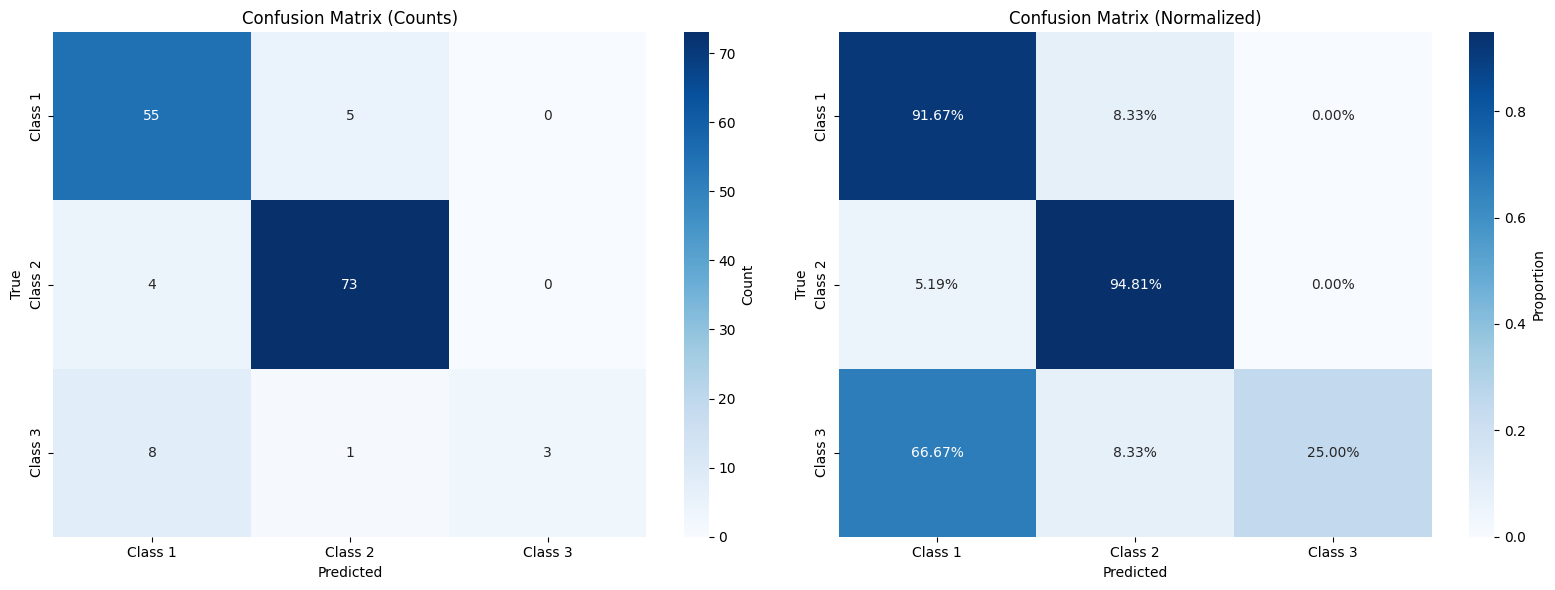

✓ Confusion matrices saved


In [ ]:
# Confusion matrices
cm = confusion_matrix(all_labels, all_preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Class 1', 'Class 2', 'Class 3'],
    yticklabels=['Class 1', 'Class 2', 'Class 3'],
    ax=axes[0], cbar_kws={'label': 'Count'}
)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_title('Confusion Matrix (Counts)')

sns.heatmap(
    cm_normalized, annot=True, fmt='.2%', cmap='Blues',
    xticklabels=['Class 1', 'Class 2', 'Class 3'],
    yticklabels=['Class 1', 'Class 2', 'Class 3'],
    ax=axes[1], cbar_kws={'label': 'Proportion'}
)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].set_title('Confusion Matrix (Normalized)')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

print("✓ Confusion matrices saved")

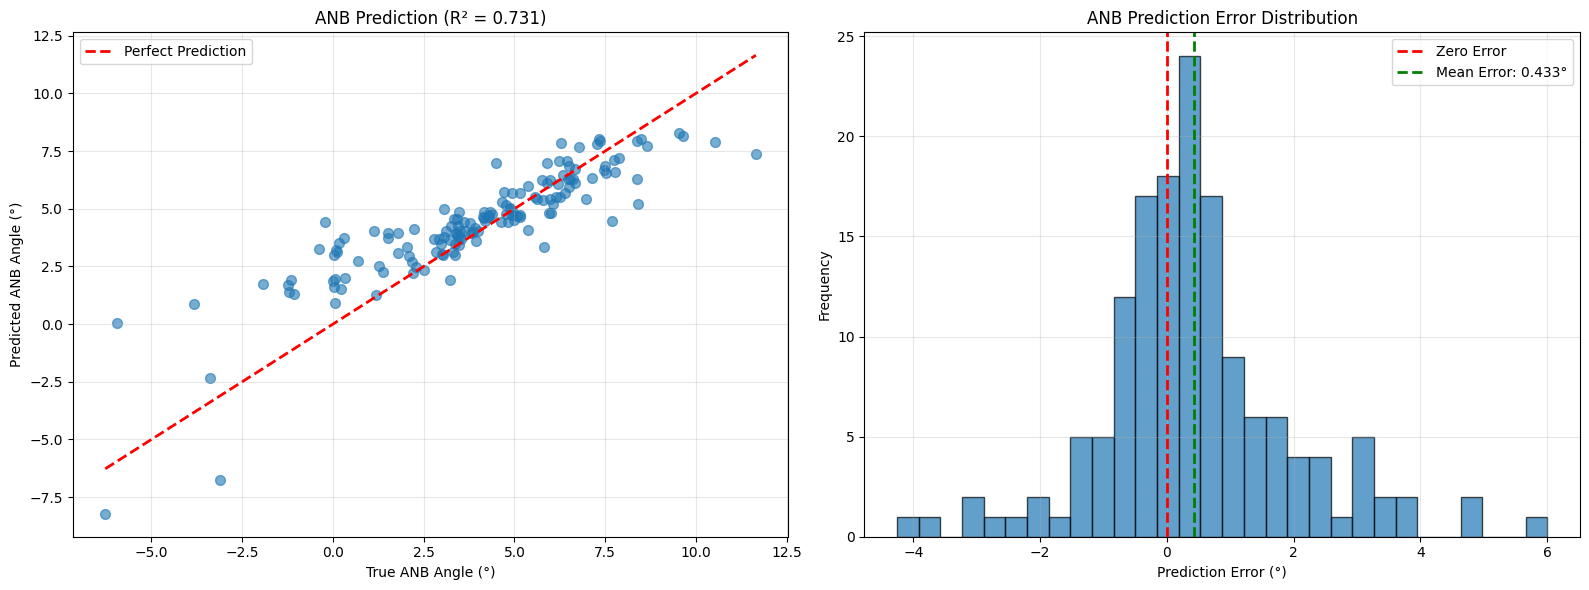

✓ ANB analysis plots saved


In [ ]:
# ANB analysis plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(all_anb_true, all_anb_preds, alpha=0.6, s=50)
axes[0].plot([all_anb_true.min(), all_anb_true.max()],
             [all_anb_true.min(), all_anb_true.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('True ANB Angle (°)')
axes[0].set_ylabel('Predicted ANB Angle (°)')
axes[0].set_title(f'ANB Prediction (R² = {r2:.3f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

errors = all_anb_preds - all_anb_true
axes[1].hist(errors, bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='r', linestyle='--', lw=2, label='Zero Error')
axes[1].axvline(errors.mean(), color='g', linestyle='--', lw=2,
                label=f'Mean Error: {errors.mean():.3f}°')
axes[1].set_xlabel('Prediction Error (°)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('ANB Prediction Error Distribution')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/anb_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

print("✓ ANB analysis plots saved")